In [1]:
# 4 electrodes -> A and B for current and M and N for potential 
# Diff. configs of these 4 electrodes 
# Dipole-dipole -> ABMN -> for lateral (horizontal) changes
# Wenner -> AMNB -> equally spaced electrodes -> for vertical changes 
# Schlumberger -> AMNB -> MN are close, A and B are far apart -> depth penetration and structural resolution

In [2]:
# sensitivity (jacobian) -> how much change there is in overall resisitivity if there is a small change in the resisitivity of 1 cell (bc relative resistivity is calc) 
# sensitivity = dd/dm where d is data and m is model params 

In [3]:
# for every cell we calc effect on voltage when resisitivity is altered
''' 1. Positive sensitivity -> V directly prop to R (dark zones in fig.)
2. Negative sensitivity -> V inversely prop to R (counter intiutive but may occue due to path of current lines) (white zones in fig.)
3. Zero sensitivity -> no effect in V when R changed '''

' 1. Positive sensitivity -> V directly prop to R (dark zones in fig.)\n2. Negative sensitivity -> V inversely prop to R (counter intiutive but may occue due to path of current lines) (white zones in fig.)\n3. Zero sensitivity -> no effect in V when R changed '

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert

In [5]:
# 3 4-point arrays for the 3 configs.
scheme = pg.DataContainerERT()

nelecs = 10
pos = np.zeros((nelecs, 2)) 
pos[:, 0] = np.linspace(5, 25, nelecs) # along first row 10 elecrrodes placed at equal distances from x=5m to x=25 m
scheme.setSensorPositions(pos) 

measurements = np.array(( # each row is a 4-point array.. first 2 coordinates are current dipoles and next 2 are potential dipoles
    [0, 3, 6, 9],  # Dipole-Dipole
    [0, 9, 3, 6],  # Wenner
    [0, 9, 4, 5]   # Schlumberger
))

for i, elec in enumerate("abmn"):
    scheme[elec] = measurements[:,i]

scheme["k"] = ert.createGeometricFactors(scheme) # rho=k*R

03/06/26 - 10:33:49 - pyGIMLi - INFO - Cache C:\Users\anves\anaconda3\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 3): C:\Users\anves\AppData\Roaming\pygimli\Cache\8884009169188508115


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

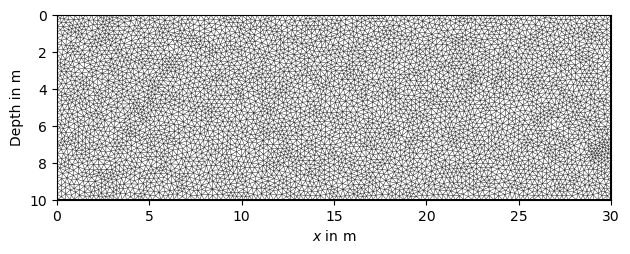

In [6]:
# 2D mesh
world = mt.createWorld(start=[0, 0], end=[30, -10], worldMarker=True) # 30x10 mesh
for pos in scheme.sensorPositions():
    world.createNode(pos)
# nodes where electrodes are present

mesh = mt.createMesh(world, area=.05, quality=33, marker=1)
pg.show(mesh)

In [7]:
fop = ert.ERTModelling() # fwd operator
fop.setData(scheme)
fop.setMesh(mesh)

model = np.ones(mesh.cellCount())
fop.createJacobian(model) # calcs sensitivity for all cells 

03/06/26 - 10:33:51 - pyGIMLi - INFO - Found 1 regions.
03/06/26 - 10:33:51 - pyGIMLi - INFO - Creating forward mesh from region infos.
03/06/26 - 10:33:51 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
03/06/26 - 10:33:51 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 20871 Cells: 41160 Boundaries: 31160


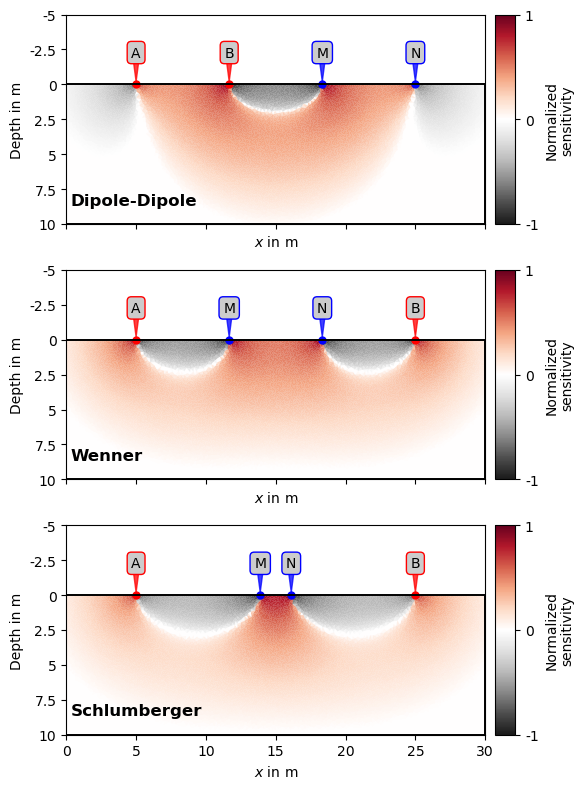

In [8]:
# final visualisation

def getABMN(scheme, idx):
    """ Get coordinates of four-point with id `idx` from DataContainerERT
    `scheme`."""
    coords = {}
    for elec in "abmn":
        elec_id = int(scheme(elec)[idx])
        elec_pos = scheme.sensorPosition(elec_id)
        coords[elec] = elec_pos.x(), elec_pos.y()
    return coords


def plotABMN(ax, scheme, idx):
    """ Visualize four-point configuration on given axes. """
    coords = getABMN(scheme, idx)
    for elec in coords:
        x, y = coords[elec]
        if elec in "ab":
            color = "red"
        else:
            color = "blue"
        # color coded 
        ax.plot(x, y, marker=".", color=color, ms=10)
        ax.annotate(elec.upper(), xy=(x, y), ha="center", fontsize=10, bbox=dict(
            boxstyle="round", fc=(0.8, 0.8, 0.8), ec=color), xytext=(0, 20),
                    textcoords='offset points', arrowprops=dict(
                        arrowstyle="wedge, tail_width=.5", fc=color, ec=color,
                        patchA=None, alpha=0.75))
        ax.plot(coords["a"][0],)
        # pointer 

labels = ["Dipole-Dipole", "Wenner", "Schlumberger"]
fig, ax = plt.subplots(scheme.size(), 1, sharex=True, figsize=(6,8))

for i, sens in enumerate(fop.jacobian()):
    # Label in lower-left corner
    ax[i].text(.01, .15, labels[i], horizontalalignment='left',
               verticalalignment='top', transform=ax[i].transAxes, fontsize=12,
               fontweight="bold")

    # Electrode annotations
    plotABMN(ax[i], scheme, i)

    # Log-scaled and normalized sensitivity
    normsens = pg.utils.logDropTol(sens/mesh.cellSizes(), 8e-4)
    normsens /= np.max(normsens)
    pg.show(mesh, normsens, cMap="RdGy_r", ax=ax[i], orientation="vertical",
            label="Normalized\nsensitivity", nLevs=3, cMin=-1, cMax=1)

fig.tight_layout()